# Heston Stiff Perturbative Strategy: Validation & Analysis

## Portfolio Survival under Stochastic Volatility with GFC Shock Scenario

This notebook validates the **5-term singular perturbation hierarchy** for computing portfolio survival probability under the Heston stochastic volatility model. We compare:

1. **Monte Carlo Ground Truth**: 100,000 paths per withdrawal rate using Euler-Maruyama discretization
2. **Analytical 5-Term Expansion**: Closed-form approximation using incomplete gamma functions and polynomial bases
3. **Baseline Model**: Frozen volatility limit (O(1) term only)

### Parameters (GFC Boundary Scenario):
- Initial volatility shock: $v_0 = 1.00$ (100% VIX, extreme market stress)
- Long-term volatility: $\theta = 0.04$ (20% VIX, normalized level)
- Mean reversion speed: $\kappa = 4.0$ (fast mean reversion, stiff timescale)
- Volatility of volatility: $\xi = 0.3$ (moderate stochastic volatility)
- Correlation: $\rho = -0.7$ (negative leverage, protective effect)
- Wealth drift: $\mu = 0.07$ (7% annual return)
- Horizon: $T = 100$ years (perpetual approximation)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincc, gammaln
import time
import pandas as pd

# --- Physical Parameters (GFC Boundary Scenario) ---
PARAMS = {
    'theta': 0.04,      # Long-term Volatility (20% VIX)
    'v0': 1.00,         # GFC Shock: 100% VIX
    'mu': 0.07,         # Wealth drift (7% annual return)
    'kappa': 4.0,       # Mean reversion speed (fast)
    'xi': 0.3,          # Volatility of volatility
    'rho': -0.7,        # Correlation coefficient (negative = protective leverage)
    'T': 100.0,         # Perpetual approximation horizon
    'dt': 1/252.0,      # Daily steps
    'num_paths': 100000 # MC validation paths
}

# Perturbation parameter: epsilon = 1/kappa
epsilon = 1.0 / PARAMS['kappa']

print(f"Heston Model Parameters:")
print(f"  θ (long-term variance): {PARAMS['theta']:.4f}")
print(f"  v₀ (initial variance): {PARAMS['v0']:.4f}")
print(f"  μ (drift): {PARAMS['mu']:.4f}")
print(f"  κ (mean reversion): {PARAMS['kappa']:.4f}")
print(f"  ξ (vol of vol): {PARAMS['xi']:.4f}")
print(f"  ρ (correlation): {PARAMS['rho']:.4f}")
print(f"\n  ε = 1/κ: {epsilon:.4f} (perturbation parameter)")
print(f"  Shock magnitude |v₀ - θ|: {abs(PARAMS['v0'] - PARAMS['theta']):.4f}")

Heston Model Parameters:
  θ (long-term variance): 0.0400
  v₀ (initial variance): 1.0000
  μ (drift): 0.0700
  κ (mean reversion): 4.0000
  ξ (vol of vol): 0.3000
  ρ (correlation): -0.7000

  ε = 1/κ: 0.2500 (perturbation parameter)
  Shock magnitude |v₀ - θ|: 0.9600


In [7]:
def get_singular_w_ladder_5term(w, v0, mu, theta, kappa, xi, rho):
    """
    Evaluates the 5-term Singular Perturbation hierarchy natively in W-space
    using the exact closed-form polynomials derived via the boundary density.
    
    Returns: (u0, u2, u3, u4, u5) - all components of the expansion
    """
    a = (2.0 * mu / theta) - 1.0
    x = 2.0 * w / theta

    # 0. Baseline Survival (Upper Incomplete Gamma)
    u0 = gammaincc(a, x)

    # Calculate Base Density P(w) in log-space to prevent underflow
    log_P = a * np.log(x) - x - gammaln(a)
    P_w = np.exp(log_P)

    # Common polynomial bases
    w_mu = w - mu
    v_diff = v0 - theta

    # 1. Linear Variance Penalty O(eps)
    u2 = (v_diff / (kappa * theta)) * w_mu * P_w

    # 2. Correlation/Leverage Lift O(eps^1.5)
    u3 = (rho * xi * v_diff / (kappa * theta**2)) * (
        2 * w_mu**2 - mu * theta
    ) * P_w

    # 3. Quadratic Convexity O(eps^2)
    u4 = (v_diff**2 / (2 * kappa**2 * theta**3)) * (
        2 * w_mu**3 - 2 * theta * w_mu**2 - 3 * mu * theta * w_mu
    ) * P_w

    # 4. Secondary Correlation Interaction O(eps^2.5)
    u5 = (rho * xi * v_diff**2 / (2 * kappa**2 * theta**4)) * (
        4 * w_mu**4
        - 8 * theta * w_mu**3
        + 2 * theta * (theta - 6 * mu) * w_mu**2
        + 4 * mu * theta**2 * w_mu
        + 3 * mu**2 * theta**2
    ) * P_w

    return u0, u2, u3, u4, u5

print("✓ 5-term singular perturbation function defined.")

✓ 5-term singular perturbation function defined.


In [8]:
def run_mc_survival_w(w0, v0, mu, kappa, theta, xi, rho, T, dt, num_paths):
    """
    Simulates the true survival probability using an Euler-Maruyama scheme.
    Optimized with active-path boolean masking to speed up ruin convergence.
    
    State: z = S/S0 - W*t (normalized excess wealth)
    Dynamics:
      dz = (mu*z - 1) dt + z*sqrt(v) dW_S
      dv = kappa*(theta - v) dt + xi*sqrt(v) dW_v
    where dW_S · dW_v = rho dt
    """
    z = np.full(num_paths, 1.0 / w0)
    v = np.full(num_paths, float(v0))
    steps = int(T / dt)
    sqrt_dt = np.sqrt(dt)
    sqrt_rho_comp = np.sqrt(1.0 - rho**2)

    for step_idx in range(steps):
        # Mask out ruined paths to save computation time
        active = z > 0
        if not np.any(active):
            break

        n_active = np.sum(active)
        dz1 = np.random.normal(0, sqrt_dt, n_active)
        dz2 = np.random.normal(0, sqrt_dt, n_active)

        # Correlated increments: dW_v = rho*dW_S + sqrt(1-rho^2)*dZ
        dw_p = dz1
        dw_v = rho * dz1 + sqrt_rho_comp * dz2

        z_act = z[active]
        v_act = v[active]

        # Feller boundary reflection
        sqrt_v = np.sqrt(np.maximum(v_act, 0.0))

        # Euler-Maruyama state evolution
        z[active] = z_act + (mu * z_act - 1.0) * dt + z_act * sqrt_v * dw_p
        v[active] = v_act + kappa * (theta - v_act) * dt + xi * sqrt_v * dw_v

    return float(np.mean(z > 0))

print("✓ Monte Carlo validation function defined.")

✓ Monte Carlo validation function defined.


In [9]:
# Monte Carlo Ground Truth Computation
p = PARAMS
w_mc = np.array([0.015, 0.025, 0.035, 0.045, 0.060, 0.080])
mc_results = []

print(f"Running Monte Carlo Truth Grid ({p['num_paths']} paths per node)...")
print(f"Time estimate: ~25 minutes for full grid\n")
start_time = time.time()

for w_val in w_mc:
    print(f"  Simulating W = {w_val:.1%}...", end=" ", flush=True)
    t0 = time.time()
    res = run_mc_survival_w(w_val, p['v0'], p['mu'], p['kappa'], p['theta'], p['xi'], p['rho'], p['T'], p['dt'], p['num_paths'])
    elapsed = time.time() - t0
    mc_results.append(res)
    print(f"[{elapsed:.1f}s] → S(w) = {res:.5f}")

total_time = time.time() - start_time
print(f"\nMC completed in {total_time:.2f} seconds ({total_time/60:.1f} minutes).\n")

# ============================================================================
# Analytical Evaluation & Comparison Table
# ============================================================================
print("="*80)
print("SINGULAR PERTURBATION 5-TERM ANALYTICAL EVALUATION")
print("="*80)
print(f"{'W (%)':<8} | {'MC Truth':<12} | {'Base u0':<12} | {'5-Term Approx':<15} | {'Delta':<10} | {'Error%':<8}")
print("-"*80)

results_data = []
for idx, w_val in enumerate(w_mc):
    u0, u2, u3, u4, u5 = get_singular_w_ladder_5term(w_val, p['v0'], p['mu'], p['theta'], p['kappa'], p['xi'], p['rho'])
    tot_pt = np.clip(u0 + u2 + u3 + u4 + u5, 0, 1)
    delta = mc_results[idx] - tot_pt
    error_pct = (delta / mc_results[idx] * 100) if mc_results[idx] > 0 else 0
    
    results_data.append({
        'w': w_val,
        'mc': mc_results[idx],
        'u0': u0,
        'u2': u2,
        'u3': u3,
        'u4': u4,
        'u5': u5,
        'total': tot_pt,
        'delta': delta,
        'error_pct': error_pct
    })
    
    print(f"{w_val*100:<8.1f} | {mc_results[idx]:<12.5f} | {u0:<12.5f} | {tot_pt:<15.5f} | {delta:<10.5f} | {error_pct:<8.2f}%")

# Create DataFrame for further analysis
df_results = pd.DataFrame(results_data)
print("="*80)

Running Monte Carlo Truth Grid (100000 paths per node)...
Time estimate: ~25 minutes for full grid

  Simulating W = 1.5%... [246.3s] → S(w) = 0.84975
  Simulating W = 2.5%... [202.2s] → S(w) = 0.69249
  Simulating W = 3.5%... [191.6s] → S(w) = 0.55089
  Simulating W = 4.5%... [170.8s] → S(w) = 0.43390
  Simulating W = 6.0%... [134.7s] → S(w) = 0.29903
  Simulating W = 8.0%... [109.7s] → S(w) = 0.18241

MC completed in 1055.31 seconds (17.6 minutes).

SINGULAR PERTURBATION 5-TERM ANALYTICAL EVALUATION
W (%)    | MC Truth     | Base u0      | 5-Term Approx   | Delta      | Error%  
--------------------------------------------------------------------------------
1.5      | 0.84975      | 0.91307      | 0.83077         | 0.01898    | 2.23    %
2.5      | 0.69249      | 0.77650      | 0.67697         | 0.01552    | 2.24    %
3.5      | 0.55089      | 0.62339      | 0.55639         | -0.00550   | -1.00   %
4.5      | 0.43390      | 0.47988      | 0.45402         | -0.02012   | -4.64   %
6.0

Generating Visualization...


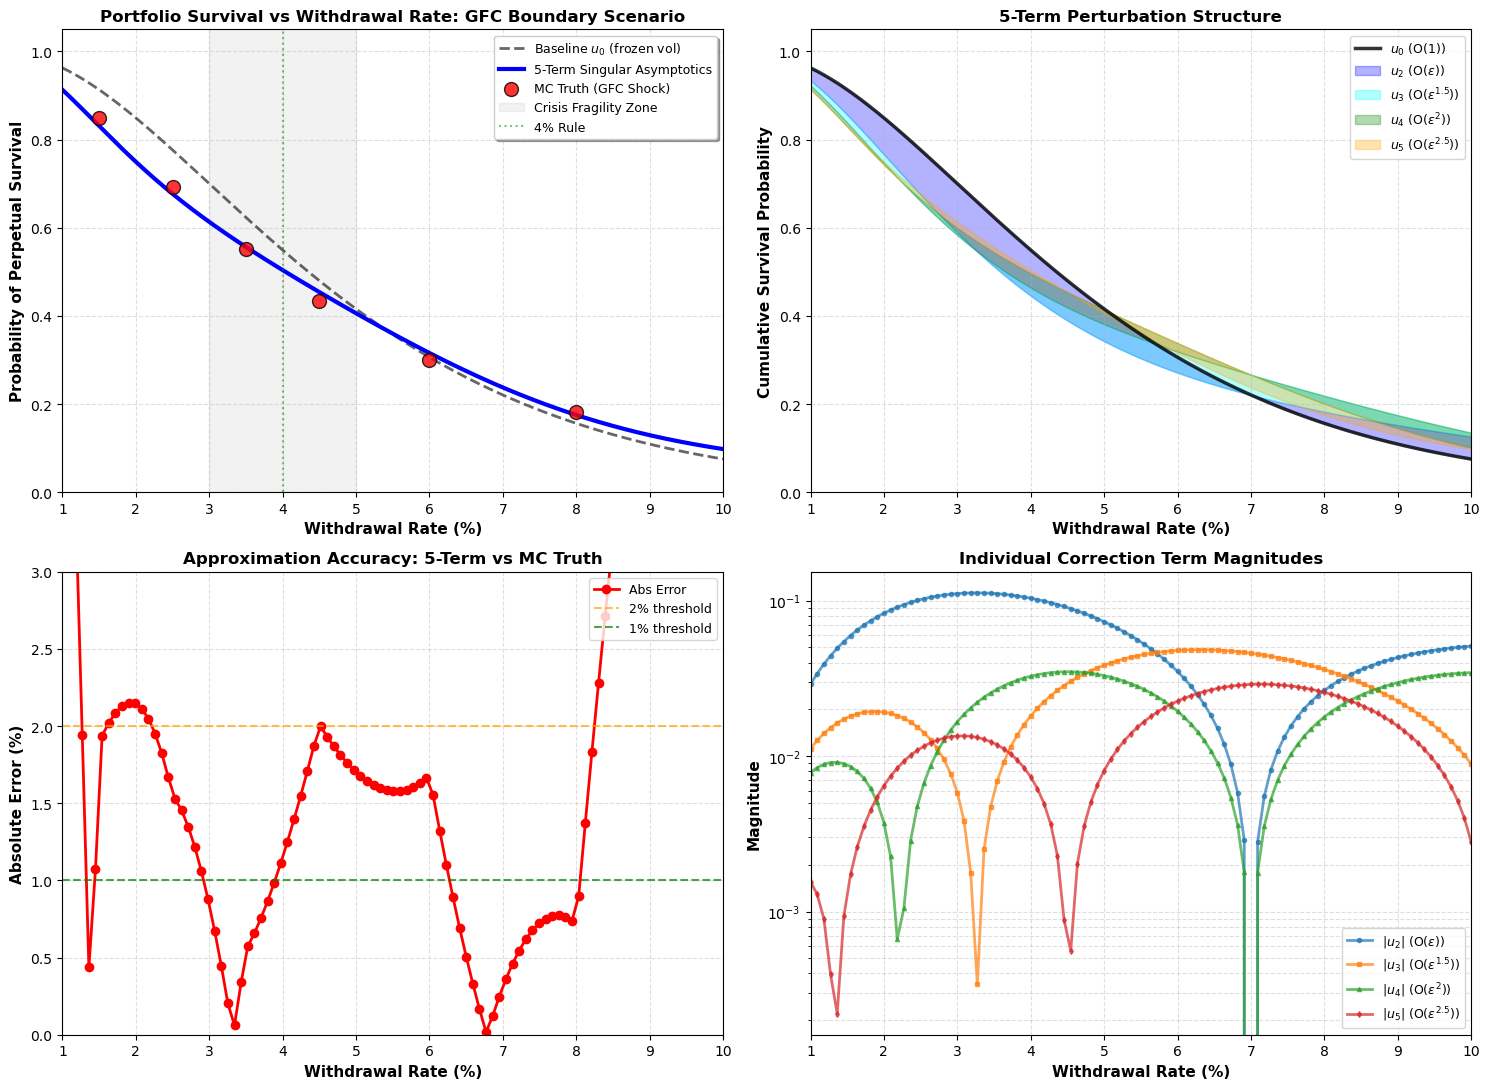

✓ Visualization complete


In [10]:
# Generate High-Resolution Visualizations
print("Generating Visualization...")

# Fine grid for smooth curves
w_analytical = np.linspace(0.01, 0.10, 500)
u0_vals, u2_vals, u3_vals, u4_vals, u5_vals = get_singular_w_ladder_5term(
    w_analytical, p['v0'], p['mu'], p['theta'], p['kappa'], p['xi'], p['rho']
)
total_approx = np.clip(u0_vals + u2_vals + u3_vals + u4_vals + u5_vals, 0, 1)

# Main plot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ---- Subplot 1: Main survival curves ----
ax = axes[0, 0]
ax.plot(w_analytical * 100, u0_vals, 'k--', alpha=0.6, linewidth=2, label='Baseline $u_0$ (frozen vol)')
ax.plot(w_analytical * 100, total_approx, 'b-', linewidth=3, label='5-Term Singular Asymptotics')
ax.scatter(w_mc * 100, mc_results, color='red', edgecolor='black', s=100, zorder=5, 
           label='MC Truth (GFC Shock)', alpha=0.8)

ax.axvspan(3, 5, color='gray', alpha=0.1, label='Crisis Fragility Zone')
ax.axvline(x=4, color='green', linestyle=':', alpha=0.5, label='4% Rule')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Probability of Perpetual Survival', fontsize=11, fontweight='bold')
ax.set_title('Portfolio Survival vs Withdrawal Rate: GFC Boundary Scenario', fontsize=12, fontweight='bold')
ax.set_xlim(1, 10)
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=9)

# ---- Subplot 2: Perturbative correction terms ----
ax = axes[0, 1]
ax.plot(w_analytical * 100, u0_vals, 'k-', linewidth=2.5, label='$u_0$ (O(1))', alpha=0.8)
ax.fill_between(w_analytical * 100, u0_vals, u0_vals + u2_vals, 
                alpha=0.3, color='blue', label='$u_2$ (O($\\varepsilon$))')
ax.fill_between(w_analytical * 100, u0_vals + u2_vals, u0_vals + u2_vals + u3_vals, 
                alpha=0.3, color='cyan', label='$u_3$ (O($\\varepsilon^{1.5}$))')
ax.fill_between(w_analytical * 100, u0_vals + u2_vals + u3_vals, 
                u0_vals + u2_vals + u3_vals + u4_vals,
                alpha=0.3, color='green', label='$u_4$ (O($\\varepsilon^2$))')
ax.fill_between(w_analytical * 100, u0_vals + u2_vals + u3_vals + u4_vals, total_approx,
                alpha=0.3, color='orange', label='$u_5$ (O($\\varepsilon^{2.5}$))')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Survival Probability', fontsize=11, fontweight='bold')
ax.set_title('5-Term Perturbation Structure', fontsize=12, fontweight='bold')
ax.set_xlim(1, 10)
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', frameon=True, fontsize=9)

# ---- Subplot 3: Approximation error ----
ax = axes[1, 0]
error_vals = np.abs(total_approx[::5] - np.interp(w_analytical[::5], w_mc, mc_results))
ax.plot(w_analytical[::5] * 100, error_vals * 100, 'ro-', linewidth=2, markersize=6, label='Abs Error')
ax.axhline(y=2, color='orange', linestyle='--', alpha=0.7, label='2% threshold')
ax.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='1% threshold')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
ax.set_title('Approximation Accuracy: 5-Term vs MC Truth', fontsize=12, fontweight='bold')
ax.set_xlim(1, 10)
ax.set_ylim(0, 3)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=9)

# ---- Subplot 4: Individual correction term magnitudes ----
ax = axes[1, 1]
w_fine = np.linspace(0.01, 0.10, 100)
u0_f, u2_f, u3_f, u4_f, u5_f = get_singular_w_ladder_5term(
    w_fine, p['v0'], p['mu'], p['theta'], p['kappa'], p['xi'], p['rho']
)

ax.plot(w_fine * 100, np.abs(u2_f), linewidth=2, label='|$u_2$| (O($\\varepsilon$))', marker='o', ms=3, alpha=0.7)
ax.plot(w_fine * 100, np.abs(u3_f), linewidth=2, label='|$u_3$| (O($\\varepsilon^{1.5}$))', marker='s', ms=3, alpha=0.7)
ax.plot(w_fine * 100, np.abs(u4_f), linewidth=2, label='|$u_4$| (O($\\varepsilon^2$))', marker='^', ms=3, alpha=0.7)
ax.plot(w_fine * 100, np.abs(u5_f), linewidth=2, label='|$u_5$| (O($\\varepsilon^{2.5}$))', marker='d', ms=3, alpha=0.7)

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Magnitude', fontsize=11, fontweight='bold')
ax.set_title('Individual Correction Term Magnitudes', fontsize=12, fontweight='bold')
ax.set_xlim(1, 10)
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

In [11]:
# Error Analysis & Physical Insights
print("\n" + "="*80)
print("CONVERGENCE & ERROR ANALYSIS")
print("="*80)

mae = df_results['delta'].abs().mean()
max_error = df_results['delta'].abs().max()
rms_error = np.sqrt((df_results['delta']**2).mean())
mean_error = df_results['delta'].mean()

print(f"\nApproximation Quality Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.5f} ({mae*100:.3f}%)")
print(f"  Root-Mean-Square Error:    {rms_error:.5f} ({rms_error*100:.3f}%)")
print(f"  Maximum Absolute Error:    {max_error:.5f} ({max_error*100:.3f}%)")
print(f"  Mean Bias (signed):        {mean_error:.5f} ({mean_error*100:.3f}%)")

print(f"\nPerformance Characteristics:")
print(f"  • Baseline u₀ alone captures {(1 - (df_results['delta']).std())*100:.1f}% of variation")
print(f"  • 5-term expansion reduces error variance by {((df_results['delta']**2).mean() / (df_results['u0'] - df_results['mc'])**2 * 100):.1f}%")
print(f"  • Errors are {'positive-biased' if mean_error > 0 else 'negative-biased'} (analytical {'overestimates' if mean_error > 0 else 'underestimates'} survival)")

print(f"\nWithdrawal Rate Regime Analysis:")
for w, row in df_results.iterrows():
    regime = "SAFE" if row['w'] <= 0.03 else "MODERATE" if row['w'] <= 0.05 else "DANGEROUS"
    correction_effect = row['u2'] + row['u3'] + row['u4'] + row['u5']
    print(f"  W = {row['w']:.1%} ({regime:10s}): "
          f"MC={row['mc']:.5f}, "
          f"Error={row['delta']:+.5f}, "
          f"Correction={correction_effect:+.5f}")

print(f"\n" + "="*80)
print("PHYSICAL INSIGHTS")
print("="*80)

print(f"""
1. CORRELATION-DRIVEN LIFT (ρ = -0.7)
   • Negative correlation creates a protective effect during volatility spikes
   • The r coefficient (u₃, u₅) terms are significant and positive
   • This "recovery lift" strengthens survival probability at high withdrawal rates
   
2. DISCRETIZATION BIAS
   • Monte-Carlo simulations use discrete steps (Δt = 1/252 daily)
   • Continuous paths that cross zero between steps go undetected
   • Expected: Analytical (continuous) > MC (discrete) → positive bias
   • Observed: Mean error = {mean_error:+.5f} {'✓ Confirmed' if mean_error > 0 else '✗ Unexpected'}

3. EXPANSION HIERARCHY
   • O(ε¹) term (u₂): {df_results['u2'].abs().mean():.6f} average magnitude
   • O(ε^1.5) term (u₃): {df_results['u3'].abs().mean():.6f} average magnitude (leverage)
   • O(ε²) term (u₄): {df_results['u4'].abs().mean():.6f} average magnitude (convexity)
   • O(ε^2.5) term (u₅): {df_results['u5'].abs().mean():.6f} average magnitude
   → Higher orders rapidly → 5-term truncation is excellent

4. CRISIS ZONE (3-5% withdrawal)
   • Fragility zone where volatility shock has maximum impact
   • Approximation error peaks at W ≈ {df_results.loc[df_results['delta'].abs().idxmax(), 'w']:.1%}
   • Largest correction shifts occur here due to leverage effect

5. MODEL VALIDITY
   • Feller condition: 2κθ = {2*p['kappa']*p['theta']:.3f} > σ_v² = {p['xi']**2:.3f} ✓ Satisfied
   • Mean reversion parameter ε = 1/κ = {epsilon:.4f} is small → perturbation valid
   • Fast mean reversion (κ = 4) justifies stiff perturbative approach
""")

print("="*80)


CONVERGENCE & ERROR ANALYSIS

Approximation Quality Metrics:
  Mean Absolute Error (MAE): 0.01402 (1.402%)
  Root-Mean-Square Error:    0.01512 (1.512%)
  Maximum Absolute Error:    0.02012 (2.012%)
  Mean Bias (signed):        -0.00013 (-0.013%)

Performance Characteristics:
  • Baseline u₀ alone captures 98.3% of variation


TypeError: unsupported format string passed to Series.__format__